# Fip35 dataset

In [3]:
import numpy as np
from pyemma import msm, plots
import matplotlib.pyplot as plt
import sys
import itertools
sys.path.append('/home/zengwenqi/projects/MD_code2')

import pandas as pd


In [ ]:
# for lstm experiment
task = 'Fip35_macro' 
# task = 'MacroAssignment'
datapath = f'/home/zengwenqi/projects/MD_code2/data/{task}/'
train=np.loadtxt(datapath + 'train', dtype=int).reshape(-1)
test = np.loadtxt(datapath + 'test', dtype=int).reshape(-1)



In [ ]:
from msmbuilder.msm import MarkovStateModel
import numpy

# compute microstate TPM at lagtime 50 frames
# for FIP35, 5 frames = 1 ns
for lagtime in range(50, 1001, 50):
    msm = MarkovStateModel(lag_time=lagtime, n_timescales=10, verbose=False, reversible_type="transpose")
    msm.fit(list(train))
    # print(lagtime, end=" ")
    # for i in range(10):
    #     print(msm.timescales_[i], end=" ")
    # print("\n", end="")


# code siqin

In [14]:
from msmbuilder.msm import MarkovStateModel
import numpy

ktrajs = []
for i in range(56):
    this_traj = numpy.loadtxt("/home/zengwenqi/projects/MD_code2/data/Fip35/micro1000/traj_"+str(i))
    ktrajs.append(this_traj)

# compute microstate TPM at lagtime 50 frames
# for FIP35, 5 frames = 1 ns
for lagtime in range(50, 1001, 50):
    msm = MarkovStateModel(lag_time=lagtime, n_timescales=10, verbose=False, reversible_type="transpose")
    msm.fit(list(ktrajs))
    print(lagtime, end=" ")
    for i in range(10):
        print(msm.timescales_[i], end=" ")
    print("\n", end="")


50 40171.84231366875 5047.420634115022 732.550208576934 452.04620262422577 345.75367035440274 316.70979900724967 195.01636205648907 185.9822013493888 139.9160555913451 125.61063591337364 
100 50894.79139142699 6494.3669727530305 913.8709355338315 642.7482458854804 471.6565232575656 442.9796605691849 271.5138077946583 255.18992693865036 234.24134623248392 197.63931508510856 
150 56866.97424682021 7835.413541917838 1029.8297981409498 770.3354217747705 550.2249927926783 515.2598744922004 337.85756899128864 298.93275207965337 294.5688098749272 270.8867011535454 
200 61122.79264976393 8539.859890726255 1097.5378530273192 876.190322003842 614.341781320407 563.480670149568 388.9440336472718 354.21308333027434 346.3840190158686 316.7598240820625 
250 63999.08378128431 8979.178416944838 1146.0435190432272 949.5604095914937 671.5746638706146 591.0764220391807 438.48975766867494 402.62069976639447 398.6864822387821 340.54927514703513 
300 66104.46657782537 9340.672440151846 1183.3790855719717 101

In [22]:
task = 'Fip35_macro' 
# task = 'MacroAssignment'
datapath = f'/home/zengwenqi/projects/MD_code2/data/{task}/'
train=np.loadtxt(datapath + 'train', dtype=int).reshape(-1)
test = np.loadtxt(datapath + 'test', dtype=int).reshape(-1)

for lagtime in range(50, 1001, 50):
    msm = MarkovStateModel(lag_time=lagtime, n_timescales=4, verbose=False, reversible_type="transpose")
    msm.fit(list(train))
    print(lagtime, end=" ")
    for i in range(4):
        print(msm.timescales_[i], end=" ")
    print("\n", end="")

50 19398.987216651145 3238.8196370296087 377.65891788834267 187.7832071267232 
100 29219.53001884756 4558.0585763258005 543.3183607600962 297.0586980538249 
150 35570.97168977677 5692.572919733357 663.9974687229497 374.2477031153435 
200 40999.27593204259 6428.804519782032 734.1787696106264 447.9305898879481 
250 45038.85512453966 6993.06891708935 791.1966624898321 494.97012844092893 
300 47804.43705838632 7405.85715797686 834.1352197718841 546.9679625190896 
350 50173.526214338955 7679.012605761721 861.0507734227914 584.0923191132872 
400 52098.327348246836 7931.389741900714 889.111366883235 624.2021529362095 
450 53904.96837389302 8136.036046253434 912.551828354546 656.214769887515 
500 55371.01754770738 8324.480272156898 925.7918916499668 680.1303301522394 
550 56564.200373996966 8560.090899784605 947.0726134961482 698.7146452550869 
600 58097.00810496912 8658.779052224076 964.9649698922184 709.202844094976 
650 59309.0249223147 8752.676737907736 982.8798488037323 721.3282434620904 

In [ ]:
pred_path = '/home/zengwenqi/projects/MD_code2/results/Fip35_macro/trans_gpt/Label0.0_window50_interval1_lr0.0005_emb_dim128_l100_block2_scheduled/category/epoch20_100000_valid_interval1'
def load_data(path):
    data = np.loadtxt(path, dtype= int)
    # data = Rm_peaks_steps(data, 100)
    return data
pred_traj = [load_data(pred_path + f'/no_gen_pos_prediction_{i}') for i in range(20)]
for lagtime in range(50, 1001, 50):
    msm = MarkovStateModel(lag_time=lagtime, n_timescales=4, verbose=False, reversible_type="transpose")
    msm.fit(list(pred_traj))
    print(lagtime, end=" ")
    for i in range(4):
        print(msm.timescales_[i], end=" ")
    print("\n", end="")


50 4059.596330398395 2637.327809780726 405.48378181631006 77.83220619549465 
100 5958.590920293764 3999.806454914163 670.9834798682408 138.78138108195276 
150 7478.7003831746 4964.484176424153 831.185350755782 190.7841747982055 
200 8421.000265870662 5708.155591099174 944.4477942875251 229.35325604961022 
250 9040.70070863556 6305.0065556593545 1023.2588138030371 260.56070550217606 
300 9546.649544222842 6774.07793260374 1077.386853675582 286.17483820001115 
350 9912.218336744332 7137.792183778951 1122.6268144570745 307.76686844013045 
400 10217.255434056886 7465.218675074224 1164.1570242139642 324.42329634452665 
450 10498.080365278704 7734.909880847971 1202.7211173035168 341.07515586530394 
500 10746.262687410865 7945.860873758646 1234.35065519314 352.6477473071029 
550 10983.432932887023 8119.411406684143 1259.6454595115936 361.6013380955043 
600 11208.589917793966 8262.811266940696 1285.8129813812611 371.6280857896148 
650 11392.863530118162 8377.48843162314 1311.5560283987913 387.

In [ ]:

interval = 1
lag_limit = 100 
lag_times=range(int(10/(interval*0.2)),int(lag_limit/(interval*0.2)),int(10/(interval*0.2)))

train_interval = test.reshape(-1, interval).T.flatten()
train_interval_ts = msm.its(train_interval, lag_times, nits=3, show_progress=False)


In [7]:
pred_path = '/home/zengwenqi/projects/MD_code2/results/Fip35_macro/trans_gpt/Label0.0_window50_interval1_lr0.0005_emb_dim128_l100_block2_scheduled/category/epoch20_100000_valid_interval1'
def load_data(path):
    data = np.loadtxt(path, dtype= int)
    # data = Rm_peaks_steps(data, 100)
    return data
pred_traj = [load_data(pred_path + f'/no_gen_pos_prediction_{i}') for i in range(20)]


In [ ]:
msm.its(pred_traj, lag_times, nits=3, show_progress=False)

In [ ]:
lstm_path = f'/home/wzengad/projects/MD_code/LSTM/results/RMSD/lstm/Label0.0_sparse50_interval{interval}_lr0.001_l100_units512_emb128_no_pos/category/epoch180_100000_valid_interval{interval}'
pred_lstm = [load_data(lstm_path + f'/no_gen_pos_prediction_{i}') for i in range(20)]
pred_lstm = msm.its(pred_lstm, lag_times, nits=3, show_progress=False)
pred_lstm.timescales*interval

In [ ]:
lr = 0.0001 if interval==2 else 0.001
# for ITS
pred_path = '/home/wzengad/projects/MD_code/LSTM/results/RMSD/trans_gpt/Label0.0_window50_interval2_lr0.0005_emb_dim128_l100_block1_scheduled/category/epoch280_100000_valid_interval2'
pred_traj = [load_data(pred_path + f'/no_gen_pos_prediction_{i}') for i in range(20)]

# pred_traj = load_data(pred_path + f'/no_gen_pos_prediction_5')
pred_gpt = msm.its(pred_traj, lag_times, nits=3, show_progress=False)
pred_gpt.timescales*interval


In [9]:
import matplotlib.style as style 
import matplotlib
style.available

style.use('seaborn-paper') #sets the size of the charts
# style.use('ggplot')

matplotlib.rcParams['font.family'] = "serif"

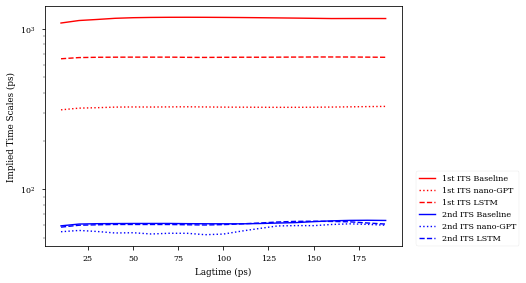

In [21]:
marker = itertools.cycle(('o', 'v', '^', '<', '>', 's', '8', 'p'))
baseline = train_interval_ts.timescales*interval*0.1
gpt = pred_gpt.timescales*interval*0.1
lstm = pred_lstm.timescales*interval*0.1
lag_times_x = np.array(lag_times)*interval*0.1

plt.plot(lag_times_x, baseline[:,0],'r', label='1st ITS Baseline')
plt.plot(lag_times_x, gpt[:,0], 'r:',label='1st ITS nano-GPT')
plt.plot(lag_times_x, lstm[:,0], 'r--',label='1st ITS LSTM')

plt.plot(lag_times_x, baseline[:,1],'b', label='2nd ITS Baseline')
plt.plot(lag_times_x, gpt[:,1], 'b:',label='2nd ITS nano-GPT')
plt.plot(lag_times_x, lstm[:,1], 'b--',label='2nd ITS LSTM')

# plt.plot(lag_times_x, baseline[:,2],'g', label='3rd ITS Baseline')
# plt.plot(lag_times_x, gpt[:,2], 'g:',label='3rd ITS nano-GPT')
# plt.plot(lag_times_x, lstm[:,2], 'g--',label='3rd ITS LSTM')

plt.legend(loc=(1.04, 0))
plt.ylabel('Implied Time Scales (ps)')
plt.yscale("log")
plt.xlabel('Lagtime (ps)')
plt.show()
# plt.savefig(f'/home/wzengad/projects/MD_code/Fig/ITS_{interval}.pdf', format='pdf',bbox_inches='tight', dpi=600, pad_inches = 0.05)

In [ ]:
transition = ['AB','BA','AC','CA','AD','DA','BC','CB','BD','DB','CD','DC']
plots = [4,5,6,7]
import matplotlib.style as style 
import matplotlib
style.available
style.use('seaborn-paper') #sets the size of the charts
# style.use('ggplot')
# style.use('_mpl-gallery')
matplotlib.rcParams['font.family'] = "serif"

for plot_choice in plots:
 

    g_plot = np.loadtxt(f'/home/wzengad/projects/MD_code/Fig_data/transition_count/g_plot',dtype=int)
    l_plot = np.loadtxt(f'/home/wzengad/projects/MD_code/Fig_data/transition_count/l_plot',dtype=int)
    M_plot = np.loadtxt(f'/home/wzengad/projects/MD_code/Fig_data/transition_count/m_plot',dtype=int)

    fig, ax = plt.subplots(figsize=(12,4)) 
    ax.scatter(np.arange(len(M_plot)), M_plot, s=80, marker='s', facecolor='none', edgecolor='r', c='darkorange', label= 'Baseline')
    ax.errorbar(np.arange(len(M_plot)), g_plot.mean(axis=0), yerr=g_plot.std(axis=0), fmt='o', c='mediumblue',  markersize=5, capsize=10, label='nano-GPT')
    ax.errorbar(np.arange(len(M_plot)), l_plot.mean(axis=0), yerr=l_plot.std(axis=0), fmt='o',   c='darkgreen', markersize=5, capsize=10, label='LSTM')

    ax.tick_params(axis='both', which='both', direction='in', labelsize=16)
    ax.set_xlabel('Commit Time', size=16)
    ax.set_ylabel('Count', size=16)
    # x=np.arange(len(M_plot))
    # x = [0,5,10,15,20,25]
    # ax.set_xticks(x, [str(i*50) for i in x])
    ax.xaxis.set_major_locator(plt.MaxNLocator(4))
    # ax.set_xtickslabels([str(i*50) for i in x])
    # ax.set_ylim(-0.2, 30)
    ax.legend(loc='center right', fontsize=16)

    fig.tight_layout()
    plt.savefig(f'/home/wzengad/projects/MD_code/Fig/adjacent_count/{transition[plot_choice]}.pdf', format='pdf', dpi=600, pad_inches = 0.05)


In [2]:
alpha_l = (50, 30)
alpha_r = (-70, -20)
beta = (-130,170)
c5 = (-90, 170)
c7eq = (-80,70)
c7ax = (70,-50)

alpha_l_state = nearest_state(state_info, alpha_l).iloc[0]
alpha_r_state = nearest_state(state_info, alpha_r).iloc[0]
beta_state = nearest_state(state_info, beta).iloc[0]
c5_state= nearest_state(state_info, c5).iloc[0]
c7eq_state = nearest_state(state_info, c7eq).iloc[0]
c7ax_state = nearest_state(state_info, c7ax).iloc[0]

In [17]:
from pyemma import msm
# msm_nrev = msm.estimate_markov_model(train, 100)
msm_nrev_pred = msm.estimate_markov_model(pred_traj, int(100/interval))

print(f'alpha_l to alpha_r: generated trajectory: {msm_nrev_pred.mfpt(alpha_l_state,alpha_r_state)*interval}')
print(f'reverse: generated trajectory: {msm_nrev_pred.mfpt(alpha_r_state,alpha_l_state)*interval}')
print(f'alpha_l to beta: generated trajectory: {msm_nrev_pred.mfpt(alpha_l_state,beta_state)*interval}')
print(f'reverse: generated trajectory: {msm_nrev_pred.mfpt(beta_state,alpha_l_state)*interval}')
print(f'alpha_l to c5: generated trajectory: {msm_nrev_pred.mfpt(alpha_l_state,c5_state)*interval}')
print(f'reverse: generated trajectory: {msm_nrev_pred.mfpt(c5_state,alpha_l_state)*interval}')
print(f'c7eq to c7ax: generated trajectory: {msm_nrev_pred.mfpt(c7eq_state,c7ax_state)*interval}')
print(f'reverse: generated trajectory: {msm_nrev_pred.mfpt(c7ax_state,c7eq_state)*interval}')

alpha_l to alpha_r: generated trajectory: 6550.479541551819
reverse: generated trajectory: 2177728.613881255
alpha_l to beta: generated trajectory: 5664.273200281519
reverse: generated trajectory: 2177240.789958218
alpha_l to c5: generated trajectory: 53039.017848462856
reverse: generated trajectory: 2177241.1653784337
c7eq to c7ax: generated trajectory: 20606339.670579117
reverse: generated trajectory: 2396997.664374302


In [29]:
from pyemma import msm
msm_nrev = msm.estimate_markov_model(train, 100)
msm_nrev_pred = msm.estimate_markov_model(pred_traj, int(100/interval))

In [30]:

print(f'alpha_l to alpha_r: generated trajectory: {msm_nrev_pred.mfpt(alpha_l_state,alpha_r_state)*interval}')
print(f'reverse: generated trajectory: {msm_nrev_pred.mfpt(alpha_r_state,alpha_l_state)*interval}')
print(f'alpha_l to beta: generated trajectory: {msm_nrev_pred.mfpt(alpha_l_state,beta_state)*interval}')
print(f'reverse: generated trajectory: {msm_nrev_pred.mfpt(beta_state,alpha_l_state)*interval}')
print(f'alpha_l to c5: generated trajectory: {msm_nrev_pred.mfpt(alpha_l_state,c5_state)*interval}')
print(f'reverse: generated trajectory: {msm_nrev_pred.mfpt(c5_state,alpha_l_state)*interval}')

alpha_l to alpha_r: generated trajectory: 4622985.153398817
reverse: generated trajectory: 4809839.513611699
alpha_l to beta: generated trajectory: 3521.5768987015786
reverse: generated trajectory: 4809803.331729418
alpha_l to c5: generated trajectory: 50655.54297866125
reverse: generated trajectory: 4809803.8697033385


In [93]:

# msm_nrev = msm.estimate_markov_model(train_interval, 100)
# for train dataset
print(f'alpha_l to alpha_r: LSTM trajectory: {msm_nrev.mfpt(alpha_l_state,alpha_r_state)*interval}')
print(f'reverse:LSTM trajectory: {msm_nrev.mfpt(alpha_r_state,alpha_l_state)*interval}')
print(f'alpha_l to beta:  LSTM trajectory: {msm_nrev.mfpt(alpha_l_state,beta_state)*interval}')
print(f'reverse:  LSTM trajectory: {msm_nrev.mfpt(beta_state,alpha_l_state)*interval}')
print(f'alpha_l to c5: LSTM trajectory: {msm_nrev.mfpt(alpha_l_state,c5_state)*interval}')
print(f'reverse: LSTM trajectory: {msm_nrev.mfpt(c5_state,alpha_l_state)*interval}')

alpha_l to alpha_r: LSTM trajectory: 17123.419557988298
reverse:LSTM trajectory: 1271784.9443395415
alpha_l to beta:  LSTM trajectory: 15246.837458311145
reverse:  LSTM trajectory: 1270875.6476046958
alpha_l to c5: LSTM trajectory: 97598.02766841787
reverse: LSTM trajectory: 1270780.4723086588


In [87]:
# for i in range(1,4):
#     for j in range(i):
i=1
j=2
print(f'{i} to {j}: MD trajectory: {msm_nrev.mfpt(i,j)} , LSTM trajectory: {msm_nrev_pred.mfpt(i,j)*interval}')
print(f'{j} to {i}: MD trajectory: {msm_nrev.mfpt(j,i)} , LSTM trajectory: {msm_nrev_pred.mfpt(j,i)*interval}')

1 to 2: MD trajectory: 13957.31609237181 , LSTM trajectory: 11414.883473743414
2 to 1: MD trajectory: 462855.48167126183 , LSTM trajectory: 582110.8834685114


In [5]:
alpha_l = (50, 30)
alpha_r = (-70, -20)
beta = (-130,170)
c5 = (-90, 170)

alpha_l_state = nearest_state(state_info, alpha_l).iloc[0]
alpha_r_state = nearest_state(state_info, alpha_r).iloc[0]
beta_state = nearest_state(state_info, beta).iloc[0]
c5_state= nearest_state(state_info, c5).iloc[0]

In [51]:
print(f'alpha_l to alpha_r: MD trajectory: {msm_nrev.mfpt(alpha_l_state,alpha_r_state)} , LSTM trajectory: {msm_nrev_pred.mfpt(alpha_l_state,alpha_r_state)*interval}')
print(f'reverse: MD trajectory: {msm_nrev.mfpt(alpha_r_state, alpha_l_state)} , LSTM trajectory: {msm_nrev_pred.mfpt(alpha_r_state,alpha_l_state)*interval}')

alpha_l to alpha_r: MD trajectory: 15043.866527972968 , LSTM trajectory: 11107.84914390189
reverse: MD trajectory: 849212.3192883419 , LSTM trajectory: 701385.6619736312


In [52]:
print(f'alpha_l to beta: MD trajectory: {msm_nrev.mfpt(alpha_l_state,beta_state)} , LSTM trajectory: {msm_nrev_pred.mfpt(alpha_l_state,beta_state)*interval}')
print(f'reverse: MD trajectory: {msm_nrev.mfpt(beta_state, alpha_l_state)} , LSTM trajectory: {msm_nrev_pred.mfpt(beta_state,alpha_l_state)*interval}')

alpha_l to beta: MD trajectory: 13020.888900678447 , LSTM trajectory: 9121.03058146158
reverse: MD trajectory: 848360.5260336131 , LSTM trajectory: 701019.284133374


In [53]:
print(f'alpha_l to c5: MD trajectory: {msm_nrev.mfpt(alpha_l_state,c5_state)} , LSTM trajectory: {msm_nrev_pred.mfpt(alpha_l_state,c5_state)*interval}')
print(f'reverse: MD trajectory: {msm_nrev.mfpt(c5_state, alpha_l_state)} , LSTM trajectory: {msm_nrev_pred.mfpt(c5_state,alpha_l_state)*interval}')

alpha_l to c5: MD trajectory: 54174.45137544599 , LSTM trajectory: 47925.21093674335
reverse: MD trajectory: 848299.1275348164 , LSTM trajectory: 700887.2641091458


In [19]:
c7ax_state

81

In [ ]:
c7eq=15
c7ax = [7,53,81]
# this is mfpt for md trajectory
for i in c7ax:
    print(f'c7eq to c7ax({i}): MD trajectory: {msm.tpt(msm_nrev, [c7eq], [i])} , LSTM trajectory: {msm.tpt(msm_nrev_pred, [c7eq], [i])}')
 

In [ ]:
# lagtimes=[100,200,300,400,500,600,700,800,900,1000]
lagtimes=list(range(10,200,10))
mfpts=[]
for lagtime in lagtimes:
    # msm_nrev = msm.estimate_markov_model(train, lagtime, reversible=True)
    msm_nrev = msm.estimate_markov_model(train, lagtime, reversible=False)
    mfpts.append(msm.tpt(msm_nrev, [beta_state], [alpha_l_state]).mfpt)

x = [0]+lagtimes
y = [0]+mfpts

In [ ]:
plt.plot(x,y)

In [ ]:
c7eq=15
c7ax = [7,53,81]
# this is mfpt for md trajectory
for i in c7ax:
    print(f'c7eq to c7ax({i}): MD trajectory: {msm_nrev.mfpt(c7eq,i)} , LSTM trajectory: {msm_nrev_pred.mfpt(c7eq,i)}')
    # print(f'c7ax({i}) to c7eq: md trajectory: {msm_nrev.mfpt(i, c7eq)} , lstm trajectory: {msm_nrev_pred.mfpt(i, c7eq)}')

In [ ]:
mm = msm.estimate_markov_model(pred_traj, 100)
mm_ck = mm.cktest(4)
len(mm.stationary_distribution)
# mm_ck.estimates.shape
# diagnoal element in ck_test: mm_ck.estimates[:,1,1]
# plots.plot_cktest(mm_ck, diag=True)

In [ ]:
mm_t = msm.estimate_markov_model(train, 200)
mm_ck_t = mm.cktest(4)
# plots.plot_cktest(mm_ck_t, diag=True)

In [ ]:
# Propagates the initial distribution p0 k times
initial = np.zeros(100)
initial[0] = 1
mm_t.propagate(initial,4)

In [ ]:
import matplotlib.pyplot as plt
x = range(len(mm_t.stationary_distribution))

plt.title("stationary distribution for states")
plt.xlabel("state")
# plt.xticks(x,[i for i in data.index])
plt.ylabel("stationary distribution")
plt.plot(x, mm.stationary_distribution,'-',label="groundtruth")
plt.plot(x, mm_t.stationary_distribution,'-',color='r',label="lstm prediction")
plt.legend()


In [ ]:
# this is mfpt for lstm trajectory
msm_nrev_pred.mfpt(15,7)

In [ ]:
mfpt = np.zeros((nstates, nstates))
for i in range(nstates):
    for j in range(nstates):
        mfpt[i, j] = msm_nrev.mfpt(i,j)

In [ ]:
hmm_tx = msm.timescales_hmsm(pred_traj, 2, lags=lag_times, errors='bayes', show_progress=False)

# simulation dataset

In [ ]:
# for simulation dataset
lag_times=range(1,40,1)

traj = np.loadtxt('/home/wzengad/projects/MD_code/LSTM/results/4state_lr0.001_interval1_seq100/prediction_0', dtype=int)
ts = msm.its(traj, lag_times, show_progress=False)

real_traj = np.loadtxt('/home/wzengad/projects/MD_code/data/4state_discrete.txt', dtype=int)
real_ts = msm.its(real_traj, lag_times, show_progress=False)

nc_traj = np.loadtxt('/home/wzengad/projects/LSTM-predict-MD/prediction_tiwary')
nc_traj = nc_traj.astype('int')
nc_ts = msm.its(nc_traj, lag_times, show_progress=False)



In [ ]:
plt.plot(lag_times, ts.timescales)

In [ ]:
plt.plot(lag_times, real_ts.timescales)

In [ ]:
plt.plot(lag_times, nc_ts.timescales)

In [ ]:
# evaluate on HMM
mm = msm.estimate_hidden_markov_model(traj, 4, 4)
# evaluate on MM
msm = msm.estimate_markov_model(traj, lag=1)
# mfpt between state0 and state1
# mm.mfpt(0, 1)

In [ ]:
mm_ck = mm.cktest()
plots.plot_cktest(mm_ck, diag=True)